In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# 1. Load raw data
df_raw = pd.read_csv('vr_hardware_master_dataset.csv')

# 2. Define our clean metrics (No BatteryTemp, BatteryLevel, GCAlloc, or CpuClock)
clean_metrics = [
    'TotalUsedMem', 'CpuUtil', 'GpuUtil', 'BatteryMicroAmps', 
    'BatteryVoltageMv', 'AvgFPS', 'WorstFrameMs', 'BestFrameMs', 
    'MainThreadMs', 'FrameTimeStdDev'
]

# 3. Aggregate data while keeping the 'location' variable
grouped = df_raw.groupby(['db_id', 'room_label', 'noise_type', 'location'])
agg_funcs = {m: ['mean', 'std', 'max', 'min', 'median'] for m in clean_metrics}
df_clean = grouped.agg(agg_funcs).reset_index()

# Flatten columns
df_clean.columns = ['_'.join(col).strip('_') for col in df_clean.columns.values]

# 4. Separate Target and Features
X_all = df_clean.drop(columns=['db_id', 'room_label', 'noise_type', 'location'], errors='ignore')
y_all = df_clean['room_label']

# 5. Run RFE
print("Extracting New Top 20 Features...")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_base, n_features_to_select=20, step=2)
rfe.fit(X_all, y_all)

new_top_20 = X_all.columns[rfe.support_].tolist()
print("\nNew Top 20 Features identified:")
for feature in new_top_20:
    print(f" - {feature}")

Extracting New Top 20 Features...

New Top 20 Features identified:
 - TotalUsedMem_mean
 - TotalUsedMem_std
 - TotalUsedMem_max
 - TotalUsedMem_min
 - TotalUsedMem_median
 - CpuUtil_mean
 - CpuUtil_median
 - GpuUtil_mean
 - GpuUtil_max
 - GpuUtil_min
 - GpuUtil_median
 - BatteryMicroAmps_mean
 - BatteryMicroAmps_max
 - BatteryMicroAmps_median
 - BatteryVoltageMv_mean
 - BatteryVoltageMv_max
 - BatteryVoltageMv_min
 - BatteryVoltageMv_median
 - AvgFPS_min
 - WorstFrameMs_median



Starting Leave-One-Location-Out Validation (20 locations)...

--- Overall LOLO Classification Report (Pure Architectural Fingerprint) ---
              precision    recall  f1-score   support

  conference       0.47      0.50      0.48        30
     hallway       0.62      0.58      0.60        26
     kitchen       0.16      0.12      0.13        26
         lab       0.53      0.67      0.59        27

    accuracy                           0.47       109
   macro avg       0.45      0.46      0.45       109
weighted avg       0.45      0.47      0.45       109

Matrix saved to 'pure_lolo_matrix.png'


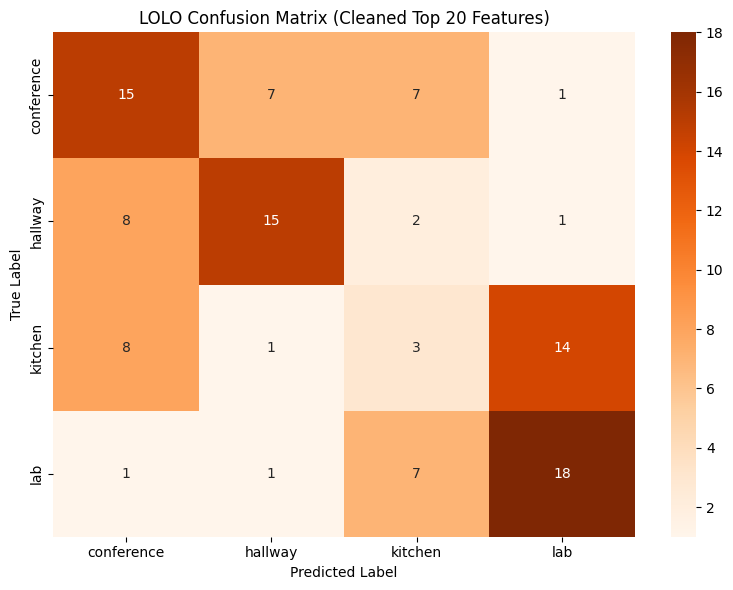

In [5]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the dataset to only use our New Top 20
X_lolo = df_clean[new_top_20]
y_lolo = df_clean['room_label']
locations = df_clean['location']

unique_locations = locations.unique()
all_y_true, all_y_pred = [], []

print(f"\nStarting Leave-One-Location-Out Validation ({len(unique_locations)} locations)...")

# 2. The LOLO Loop
for loc in unique_locations:
    train_idx = locations != loc
    test_idx = locations == loc
    
    X_train, y_train = X_lolo[train_idx], y_lolo[train_idx]
    X_test, y_test = X_lolo[test_idx], y_lolo[test_idx]
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# 3. Print Results
print("\n--- Overall LOLO Classification Report (Pure Architectural Fingerprint) ---")
print(classification_report(all_y_true, all_y_pred))

# 4. Optional: Save a Confusion Matrix
plt.figure(figsize=(8, 6))
cm = pd.crosstab(pd.Series(all_y_true, name='True Label'), pd.Series(all_y_pred, name='Predicted Label'))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('LOLO Confusion Matrix (Cleaned Top 20 Features)')
plt.tight_layout()
plt.savefig('pure_lolo_matrix.png')
print("Matrix saved to 'pure_lolo_matrix.png'")